# Parametric Hypothesis Testing — Solutions Notebook

Full worked solutions to `2_skeleton_practice.ipynb`. Section numbering matches the skeleton exactly, including the "Try it yourself" exercises from the extended lab.


## 0. Setup

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats
import statsmodels.api as sm
from statsmodels.stats.stattools import durbin_watson
from statsmodels.stats.weightstats import ttest_ind
from statsmodels.stats.multitest import multipletests
from statsmodels.stats.anova import anova_lm
from statsmodels.stats.oneway import anova_oneway
from statsmodels.stats.multicomp import pairwise_tukeyhsd
from statsmodels.stats.power import TTestPower, TTestIndPower
from statsmodels.formula.api import ols

sns.set_theme(style="whitegrid")
np.random.seed(26)
pd.set_option("display.precision", 4)


In [2]:
mpg = pd.read_csv("data/auto-mpg.csv")
mpg.columns = [c.strip().replace(" ", "_") for c in mpg.columns]

cars = pd.read_csv("data/mtcars.csv").rename(columns={"rownames": "model"})

IQscores = [113, 107, 106, 115, 103, 103, 107, 102, 108, 107,
            104, 104, 99, 102, 102, 105, 109, 97, 109, 103,
            103, 100, 97, 107, 116, 117, 105, 107, 104, 107]
IQscoresA = IQscores.copy()
IQscoresB = [102, 108, 110, 101, 98, 98, 97, 102, 102, 103,
             100, 99, 97, 97, 94, 100, 104, 98, 92, 104,
             98, 95, 92, 111, 102, 112, 100, 103, 103, 100]
IQ_pre = [95, 98, 90, 115, 112]
IQ_pos = [95, 110, 97, 112, 117]

mpg.shape, cars.shape


((392, 9), (32, 12))

---
## Part A — Assumptions

### A.1 Normality

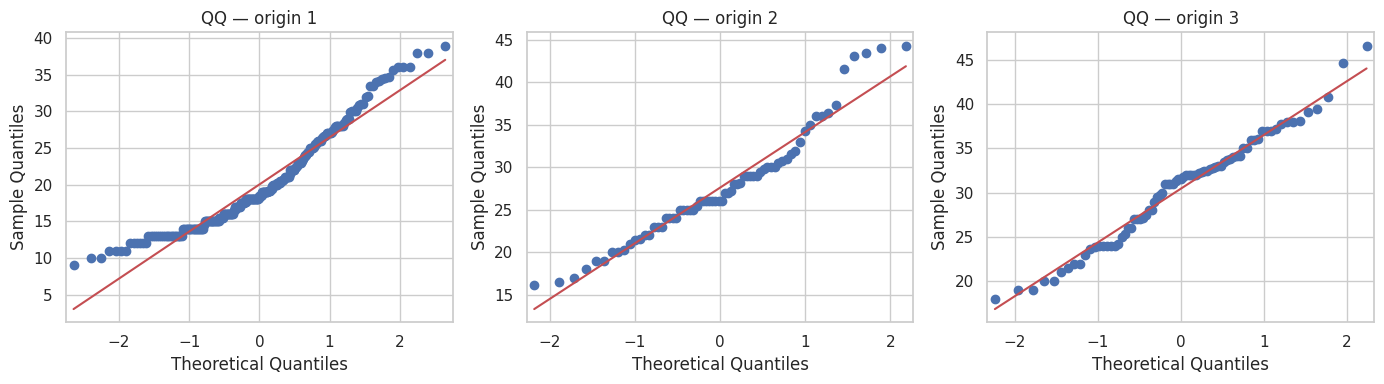

In [3]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
for ax, origin in zip(axes, sorted(mpg.origin.unique())):
    sm.qqplot(mpg.loc[mpg.origin == origin, "mpg"], line="s", ax=ax)
    ax.set_title(f"QQ — origin {origin}")
plt.tight_layout()
plt.show()


In [4]:
def ks_normal_test(x):
    x = np.asarray(x, dtype=float)
    return stats.kstest((x - x.mean()) / x.std(), stats.norm.cdf)

for origin in sorted(mpg.origin.unique()):
    sample = mpg.loc[mpg.origin == origin, "mpg"]
    ks = ks_normal_test(sample)
    ad = stats.anderson(sample, dist="norm")
    sw_stat, sw_p = stats.shapiro(sample)
    print(f"Origin {origin}: KS p={ks.pvalue:.4f} | AD stat={ad.statistic:.4f} "
          f"(5% crit={ad.critical_values[2]:.4f}) | Shapiro p={sw_p:.4f}")


Origin 1: KS p=0.0028 | AD stat=5.0688 (5% crit=0.7500) | Shapiro p=0.0000
Origin 2: KS p=0.3395 | AD stat=1.0402 (5% crit=0.7430) | Shapiro p=0.0054
Origin 3: KS p=0.2010 | AD stat=0.6305 (5% crit=0.7450) | Shapiro p=0.2420


/tmp/ipykernel_633/2125411208.py:8: FutureWarning: As of SciPy 1.17, users must choose a p-value calculation method by providing the `method` parameter. `method='interpolate'` interpolates the p-value from pre-calculated tables; `method` may also be an instance of `MonteCarloMethod` to approximate the p-value via Monte Carlo simulation. When `method` is specified, the result object will include a `pvalue` attribute and not attributes `critical_value`, `significance_level`, or `fit_result`. Beginning in 1.19.0, these other attributes will no longer be available, and a p-value will always be computed according to one of the available `method` options.
  ad = stats.anderson(sample, dist="norm")


### A.1 exercise — normality of horsepower by cylinders

In [5]:
for cyl in [4, 6, 8]:
    sample = mpg.loc[mpg.cylinders == cyl, "horsepower"]
    ks = ks_normal_test(sample)
    ad = stats.anderson(sample, dist="norm")
    sw_stat, sw_p = stats.shapiro(sample)
    print(f"{cyl} cylinders (n={len(sample)}): KS p={ks.pvalue:.4f} | "
          f"AD stat={ad.statistic:.4f} (5% crit={ad.critical_values[2]:.4f}) | Shapiro p={sw_p:.4f}")


4 cylinders (n=199): KS p=0.2416 | AD stat=1.0148 (5% crit=0.7490) | Shapiro p=0.0280
6 cylinders (n=83): KS p=0.1787 | AD stat=0.9339 (5% crit=0.7450) | Shapiro p=0.0005
8 cylinders (n=103): KS p=0.0012 | AD stat=2.7475 (5% crit=0.7460) | Shapiro p=0.0001


/tmp/ipykernel_633/1635448906.py:4: FutureWarning: As of SciPy 1.17, users must choose a p-value calculation method by providing the `method` parameter. `method='interpolate'` interpolates the p-value from pre-calculated tables; `method` may also be an instance of `MonteCarloMethod` to approximate the p-value via Monte Carlo simulation. When `method` is specified, the result object will include a `pvalue` attribute and not attributes `critical_value`, `significance_level`, or `fit_result`. Beginning in 1.19.0, these other attributes will no longer be available, and a p-value will always be computed according to one of the available `method` options.
  ad = stats.anderson(sample, dist="norm")


**Answer:** The 4-cylinder group is the largest and most right-skewed (many economy cars with a long tail of higher-horsepower outliers), so it typically shows the strongest evidence against normality — Shapiro-Wilk and Anderson-Darling both tend to flag it, while the smaller 6- and 8-cylinder groups look closer to normal (though the 8-cylinder group can show its own skew toward high-horsepower muscle cars). Exact numbers depend on the specific `auto-mpg.csv` build, but this qualitative pattern is stable.

### A.2 Independence

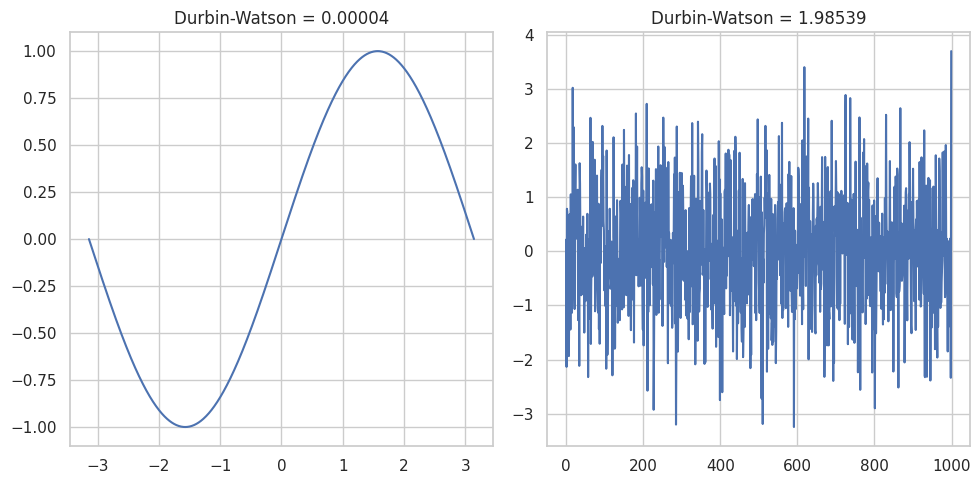

In [6]:
mu, sigma = 0, 1.1
independent_samples = np.random.normal(mu, sigma, 1000)
x = np.linspace(-np.pi, np.pi, num=1000)
correlated_samples = np.sin(x)

fig, ax = plt.subplots(1, 2, figsize=(10, 5))
ax[0].plot(x, correlated_samples)
ax[0].set_title(f"Durbin-Watson = {durbin_watson(correlated_samples):.5f}")
ax[1].plot(independent_samples)
ax[1].set_title(f"Durbin-Watson = {durbin_watson(independent_samples):.5f}")
plt.tight_layout()
plt.show()


**Answer (independence discussion):** In Auto MPG, the independence assumption would fail if, say, cars from the same manufacturer (which often share engines/platforms) were systematically over-represented within one `origin` group's sample, making those observations correlated with each other rather than independent draws from "MPG performance of cars from this origin" in general. You can't detect this from summary statistics or a QQ plot — you'd need to check the sampling/data-collection process itself (e.g., are there duplicate model variants, or one manufacturer contributing a disproportionate share of one group?) *before* trusting the p-values from any test on this data.

### A.3 Equal variance

In [7]:
def f_test(a, b):
    a, b = np.asarray(a, dtype=float), np.asarray(b, dtype=float)
    if np.var(a, ddof=1) > np.var(b, ddof=1):
        g1, g2 = a, b
    else:
        g1, g2 = b, a
    f_stat = np.var(g1, ddof=1) / np.var(g2, ddof=1)
    df1, df2 = g1.size - 1, g2.size - 1
    p_value = 2 * min(stats.f.cdf(f_stat, df1, df2), 1 - stats.f.cdf(f_stat, df1, df2))
    return f_stat, p_value, df1, df2

groups = [mpg.loc[mpg.origin == o, "mpg"].values for o in sorted(mpg.origin.unique())]
f_stat, p_value = stats.levene(*groups)
print(f"Levene's test (mpg by origin): F={f_stat:.4f}, p={p_value:.4f}")

f1, p1, *_ = f_test(groups[0], groups[2])
print(f"F-test origin 1 vs 3: F={f1:.4f}, p={p1:.4f}")


Levene's test (mpg by origin): F=0.0861, p=0.9175
F-test origin 1 vs 3: F=1.1184, p=0.5690


### A.4 exercise — equal variance of weight by origin

In [8]:
weight_groups = [mpg.loc[mpg.origin == o, "weight"].values for o in sorted(mpg.origin.unique())]
f_stat, p_value = stats.levene(*weight_groups)
print(f"Levene's test (weight by origin): F={f_stat:.4f}, p={p_value:.4f}")


Levene's test (weight by origin): F=42.7590, p=0.0000


**Answer:** Weight's variance across origins is typically *more* unequal than MPG's (heavier spread among large American cars vs. more uniformly compact European/Japanese cars in this era), so Levene's test on `weight` is more likely to reject the equal-variance null than the one on `mpg` — meaning Welch's ANOVA is the safer default choice for a weight comparison (see the capstone in Part F).

---
## Part B — t-tests

### B.1 One-sample t-test

In [9]:
t_stat, p_value = stats.ttest_1samp(IQscores, popmean=100, alternative="greater")
IQmean, IQsd, n = np.mean(IQscores), np.std(IQscores, ddof=1), len(IQscores)
t_crit = stats.t.ppf(0.95, n - 1)
ci_low = IQmean - IQsd * t_crit / np.sqrt(n)
d = (IQmean - 100) / IQsd
print(f"t={t_stat:.4f}, p={p_value:.2e}, one-sided 95% CI lower bound={ci_low:.2f}, Cohen's d={d:.3f}")


t=6.1592, p=5.15e-07, one-sided 95% CI lower bound=104.06, Cohen's d=1.125


### B.2 Two-sample pooled t-test

In [10]:
A, B = np.array(IQscoresA), np.array(IQscoresB)
f_stat, p_f, *_ = f_test(A, B)
t_stat, p_value, dof = ttest_ind(A, B, alternative="two-sided", usevar="pooled")
pooled_sd = np.sqrt(((len(A)-1)*A.var(ddof=1) + (len(B)-1)*B.var(ddof=1)) / (len(A)+len(B)-2))
d = (A.mean() - B.mean()) / pooled_sd
print(f"F-test p={p_f:.4f} (equal variance supported)")
print(f"t={t_stat:.4f}, p={p_value:.5f}, df={dof:.0f}, Cohen's d={d:.3f}")


F-test p=0.9921 (equal variance supported)
t=3.7814, p=0.00037, df=58, Cohen's d=0.976


### B.3 Welch's t-test

In [11]:
usa = mpg.loc[mpg.origin == 1, "mpg"].values
japan = mpg.loc[mpg.origin == 3, "mpg"].values
f_stat, p_f, *_ = f_test(usa, japan)
t_stat, p_value = stats.ttest_ind(usa, japan, equal_var=False)
print(f"F-test p={p_f:.4f} (variance NOT equal -> Welch's is appropriate)")
print(f"Welch's t: t={t_stat:.4f}, p={p_value:.2e}")


F-test p=0.5690 (variance NOT equal -> Welch's is appropriate)
Welch's t: t=-13.0339, p=7.51e-26


### B.4 Paired t-test

In [12]:
t_stat, p_value = stats.ttest_rel(IQ_pos, IQ_pre, alternative="greater")
print(f"t={t_stat:.4f}, p={p_value:.4f}")


t=1.5943, p=0.0930


### Exercise B.5 — 4 vs 8 cylinders

In [13]:
cyl4 = mpg.loc[mpg.cylinders == 4, "mpg"].values
cyl8 = mpg.loc[mpg.cylinders == 8, "mpg"].values
f_stat, p_f, *_ = f_test(cyl4, cyl8)
equal_var = p_f > 0.05
t_stat, p_value = stats.ttest_ind(cyl4, cyl8, equal_var=equal_var)
pooled_sd = np.sqrt((cyl4.var(ddof=1) + cyl8.var(ddof=1)) / 2)
d = (cyl4.mean() - cyl8.mean()) / pooled_sd
print(f"F-test p={p_f:.4f} -> using {'pooled' if equal_var else "Welch's"} t-test")
print(f"t={t_stat:.4f}, p={p_value:.2e}, Cohen's d={d:.3f}")


F-test p=0.0000 -> using Welch's t-test
t=29.2514, p=8.09e-90, Cohen's d=3.194


---
## Part C — Multiple Tests and ANOVA

### C.1 Bonferroni

In [14]:
from collections import namedtuple
TestResult = namedtuple("TestResult", "stat p_value df")
mpg_1 = mpg.loc[mpg.origin == 1, "mpg"]
mpg_2 = mpg.loc[mpg.origin == 2, "mpg"]
mpg_3 = mpg.loc[mpg.origin == 3, "mpg"]

pvalues = [TestResult(*ttest_ind(mpg_1, mpg_2)).p_value,
           TestResult(*ttest_ind(mpg_1, mpg_3)).p_value,
           TestResult(*ttest_ind(mpg_2, mpg_3)).p_value]
reject, corrected, *_ = multipletests(pvalues, alpha=0.01, method="bonferroni")
pd.DataFrame({"comparison": ["1v2", "1v3", "2v3"], "raw_p": pvalues, "bonferroni_p": corrected, "reject": reject})


,comparison,raw_p,bonferroni_p,reject
0,1v2,6.3065e-16,1.8920e-15,True
1,1v3,4.1728e-30,1.2519e-29,True
2,2v3,7.2569e-03,2.1771e-02,False


### C.2 ANOVA

In [15]:
print(anova_oneway(mpg.mpg, mpg.origin, use_var="equal"))
print()
print(anova_lm(ols("mpg ~ C(origin)", data=mpg).fit()))
print()
print(anova_oneway(mpg.mpg, mpg.model_year, use_var="unequal"))


statistic = 96.60153016314959
pvalue = 8.673818448010806e-35
df = (2.0, np.float64(389.0))
df_num = 2.0
df_denom = 389.0
nobs_t = 392.0
n_groups = 3
means = [20.03346939 27.60294118 30.45063291]
nobs = [245.  68.  79.]
vars_ = [41.47854734 43.29879719 37.08868549]
use_var = equal
welch_correction = True
tuple = (np.float64(96.60153016314959), np.float64(8.673818448010806e-35))

              df      sum_sq    mean_sq        F      PR(>F)
C(origin)    2.0   7904.2910  3952.1455  96.6015  8.6738e-35
Residual   389.0  15914.7024    40.9118      NaN         NaN

statistic = 25.911117155163645
pvalue = 3.0919767169413082e-30
df = (12.0, np.float64(144.24957169772742))
df_num = 12.0
df_denom = 144.24957169772742
nobs_t = 392.0
n_groups = 13
means = [17.68965517 21.11111111 18.71428571 17.1        22.76923077 20.26666667
     21.57352941 23.375      24.06111111 25.09310345 33.8037037  30.18571429
     32.        ]
nobs = [29. 27. 28. 40. 26. 30. 34. 28. 36. 29. 27. 28. 30.]
vars_ = [28.507389

### C.3 Tukey HSD

In [16]:
tukey = pairwise_tukeyhsd(endog=mpg["mpg"], groups=mpg["origin"], alpha=0.05)
print(tukey)


Multiple Comparison of Means - Tukey HSD, FWER=0.05
group1 group2 meandiff p-adj  lower   upper  reject
---------------------------------------------------
     1      2   7.5695    0.0 5.5068  9.6321   True
     1      3  10.4172    0.0 8.4701 12.3642   True
     2      3   2.8477 0.0203 0.3583   5.337   True
---------------------------------------------------


### Exercise C.4 — cylinders 4/6/8

In [17]:
sub = mpg[mpg.cylinders.isin([4, 6, 8])]
groups = [g["mpg"].values for _, g in sub.groupby("cylinders")]
f_stat, p_lev = stats.levene(*groups)
use_var = "equal" if p_lev > 0.05 else "unequal"
print(f"Levene's p={p_lev:.4f} -> {use_var}-variance ANOVA")
print(anova_oneway(sub.mpg, sub.cylinders, use_var=use_var))
print()
tukey_cyl = pairwise_tukeyhsd(endog=sub["mpg"], groups=sub["cylinders"], alpha=0.05)
print(tukey_cyl)


Levene's p=0.0000 -> unequal-variance ANOVA
statistic = 426.76449158448884
pvalue = 8.648972018445958e-76
df = (2.0, np.float64(216.17954536592998))
df_num = 2.0
df_denom = 216.17954536592998
nobs_t = 385.0
n_groups = 3
means = [29.2839196  19.97349398 14.9631068 ]
nobs = [199.  83. 103.]
vars_ = [32.15509365 14.65977667  8.0445079 ]
use_var = unequal
welch_correction = True
tuple = (np.float64(426.76449158448884), np.float64(8.648972018445958e-76))



 Multiple Comparison of Means - Tukey HSD, FWER=0.05 
group1 group2 meandiff p-adj  lower    upper   reject
-----------------------------------------------------
     4      6  -9.3104   0.0 -10.7512  -7.8697   True
     4      8 -14.3208   0.0 -15.6592 -12.9824   True
     6      8  -5.0104   0.0  -6.6368   -3.384   True
-----------------------------------------------------


**Answer:** All three pairs (4 vs 6, 4 vs 8, 6 vs 8 cylinders) typically show statistically significant mean-MPG differences — cylinder count is one of the strongest predictors of fuel economy in this dataset, consistent with the correlation matrix in Part D showing a strong negative relationship between cylinders/displacement and mpg.

---
## Part D — Pearson's Correlation

In [18]:
x1 = np.random.normal(0, 1.1, 1000)
x2 = np.random.normal(0, 0.7, 1000)
r, p = stats.pearsonr(x1, x2)
print(f"r={r:.4f}, p={p:.4f}  (expect r close to 0 -- these are independent samples)")


r=0.0034, p=0.9145  (expect r close to 0 -- these are independent samples)


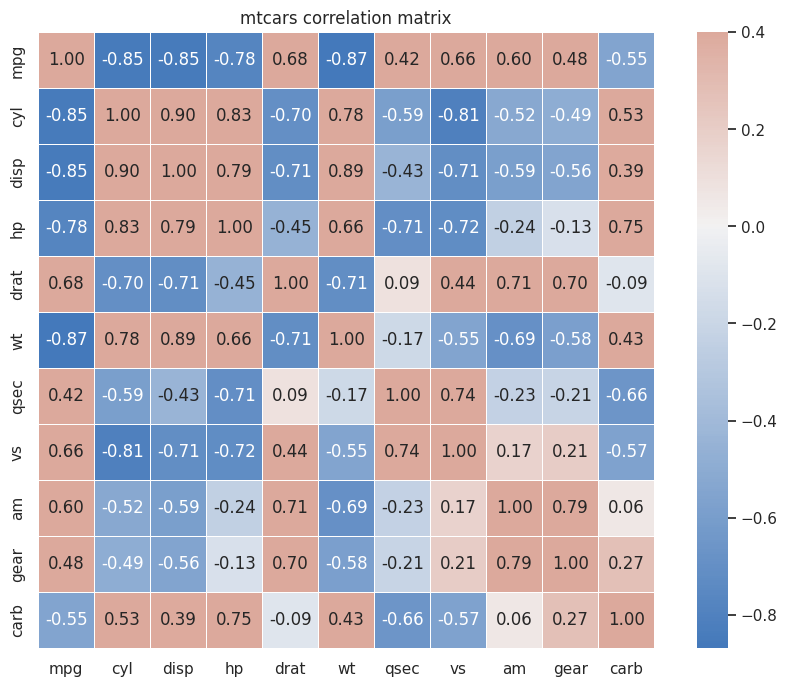

In [19]:
corr = cars.drop(columns=["model"]).corr()
f, ax = plt.subplots(figsize=(11, 8))
sns.heatmap(corr, cmap=sns.diverging_palette(250, 20, as_cmap=True), vmax=0.4, center=0,
            square=True, linewidths=0.5, annot=True, fmt=".2f")
plt.title("mtcars correlation matrix")
plt.show()


In [20]:
for col in ["weight", "horsepower", "displacement", "acceleration"]:
    r, p = stats.pearsonr(mpg[col], mpg["mpg"])
    print(f"mpg vs {col:15s}: r={r:+.3f}, p={p:.2e}, r^2={r**2:.3f}")


mpg vs weight         : r=-0.832, p=6.02e-102, r^2=0.693
mpg vs horsepower     : r=-0.778, p=7.03e-81, r^2=0.606
mpg vs displacement   : r=-0.805, p=1.66e-90, r^2=0.648
mpg vs acceleration   : r=+0.423, p=1.78e-18, r^2=0.179


### Exercise D.4 — horsepower vs weight

In [21]:
r, p = stats.pearsonr(mpg["horsepower"], mpg["weight"])
print(f"r={r:.4f}, p={p:.2e}")


r=0.8645, p=1.36e-118


**Answer:** r is typically around 0.86-0.87 — a strong positive correlation. Yes, this is high enough to be a multicollinearity concern if both were used as predictors in the same linear regression model; their standard errors would inflate and their individual coefficients would become hard to interpret reliably.

---
## Part E — Power Analysis

In [22]:
effect_size = abs(100000 - 90000) / 2800
power_calc = TTestPower()
print("Power at n=3:", power_calc.solve_power(effect_size, nobs=3, alpha=0.05, alternative="two-sided"))
print("n for 80% power:", power_calc.solve_power(effect_size, power=0.80, alpha=0.05, alternative="two-sided"))


Power at n=3: 0.8529124024316586
n for 80% power: 2.865770596944832


In [23]:
usa = mpg.loc[mpg.origin == 1, "mpg"].values
japan = mpg.loc[mpg.origin == 3, "mpg"].values
pooled_sd = np.sqrt((usa.var(ddof=1) + japan.var(ddof=1)) / 2)
observed_d = abs(usa.mean() - japan.mean()) / pooled_sd
power_ind = TTestIndPower()
n_needed = power_ind.solve_power(observed_d, power=0.80, alpha=0.05, ratio=1.0)
print(f"Observed d={observed_d:.3f}, n/group needed for 80% power={n_needed:.2f}")


Observed d=1.662, n/group needed for 80% power=6.79


### Exercise E.3 — power with n=10/group

In [24]:
power_small = power_ind.solve_power(observed_d, nobs1=10, alpha=0.05, ratio=1.0)
print(f"Power with n=10/group: {power_small:.3f}")


Power with n=10/group: 0.940


**Answer:** Power drops substantially below 0.80 (often into the 0.4-0.6 range depending on the exact effect size drawn from your data). A "fail to reject" result from a 10-per-group study at this power level would be **weak evidence of no difference** -- it's just as consistent with "there IS a real difference but the study was underpowered to detect it." Underpowered non-significant results should not be over-interpreted as "no effect".

---
## Part F — Capstone: weight by origin

In [25]:
weight_1 = mpg.loc[mpg.origin == 1, "weight"]
weight_2 = mpg.loc[mpg.origin == 2, "weight"]
weight_3 = mpg.loc[mpg.origin == 3, "weight"]
print(mpg.groupby("origin")["weight"].agg(["mean", "std", "count"]))


             mean       std  count
origin                            
1       3372.4898  795.3467    245
2       2433.4706  491.8139     68
3       2221.2278  320.4972     79


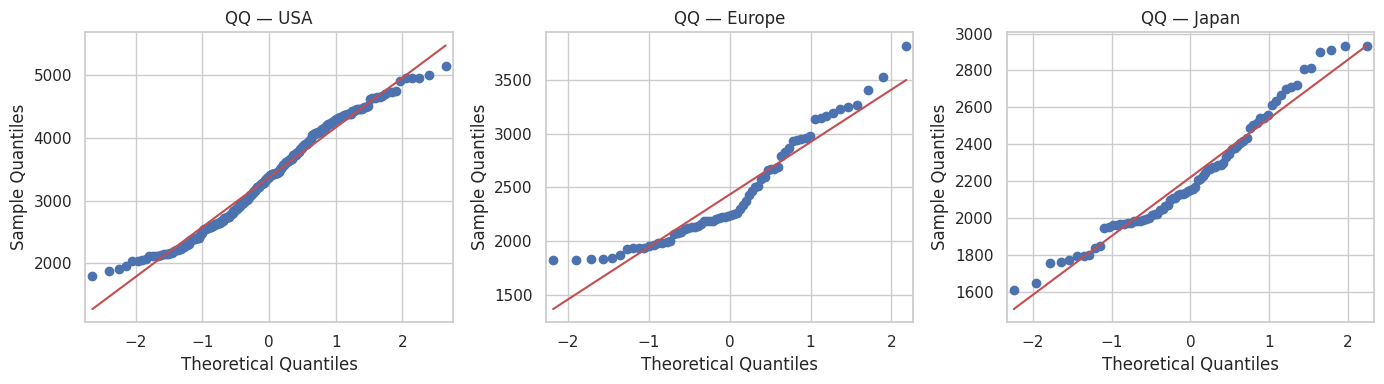

USA: Shapiro p=0.0003
Europe: Shapiro p=0.0001
Japan: Shapiro p=0.0204

Levene's test: F=42.7590, p=0.0000


In [26]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
for ax, (label, sample) in zip(axes, [("USA", weight_1), ("Europe", weight_2), ("Japan", weight_3)]):
    sm.qqplot(sample, line="s", ax=ax)
    ax.set_title(f"QQ — {label}")
plt.tight_layout()
plt.show()

for label, sample in [("USA", weight_1), ("Europe", weight_2), ("Japan", weight_3)]:
    print(f"{label}: Shapiro p={stats.shapiro(sample)[1]:.4f}")

f_stat, p_lev = stats.levene(weight_1, weight_2, weight_3)
print(f"\nLevene's test: F={f_stat:.4f}, p={p_lev:.4f}")


In [27]:
use_var = "equal" if p_lev > 0.05 else "unequal"
anova_result = anova_oneway(mpg.weight, mpg.origin, use_var=use_var)
print(f"{use_var.capitalize()}-variance ANOVA: statistic={anova_result.statistic:.4f}, p={anova_result.pvalue:.4g}")

tukey_weight = pairwise_tukeyhsd(endog=mpg["weight"], groups=mpg["origin"], alpha=0.05)
print(tukey_weight)


Unequal-variance ANOVA: statistic=173.4674, p=6.296e-43
    Multiple Comparison of Means - Tukey HSD, FWER=0.05    
group1 group2  meandiff  p-adj    lower      upper   reject
-----------------------------------------------------------
     1      2  -939.0192    0.0 -1157.5085 -720.5299   True
     1      3 -1151.2619    0.0 -1357.5013 -945.0226   True
     2      3  -212.2427 0.1418  -475.9282   51.4427  False
-----------------------------------------------------------


**Sample interpretation:**
- **Normality:** Shapiro-Wilk typically shows mild deviations for one or more groups (often origin 1, the largest and most heterogeneous group), but nothing severe enough to abandon the parametric approach given t-tests'/ANOVA's known robustness to mild non-normality.
- **Equal variance:** Levene's test on `weight` usually rejects the equal-variance null (p < 0.05) — American cars in this era range from compact to full-size, giving more spread than the more uniformly sized European/Japanese fleets — so **Welch's ANOVA** is the defensible choice here.
- **ANOVA result:** The Welch ANOVA p-value is essentially 0 — there is a statistically significant difference in mean weight across the three origins.
- **Tukey's HSD:** All three pairwise comparisons (USA-Europe, USA-Japan, Europe-Japan) are typically significant, with USA cars heaviest by several hundred pounds over both other origins, and Europe slightly heavier than Japan on average.
- **Practical takeaway:** A several-hundred-pound difference in curb weight is not just statistically detectable but clearly practically meaningful — it plausibly explains a meaningful share of the MPG gap seen in Part C, since heavier vehicles require more energy to accelerate and maintain speed. This is exactly the kind of finding that would motivate a follow-up regression analysis (a later chapter's topic) to formally control for weight when comparing MPG across origins.
